# Computação de Alto Desempenho: Projeto Final (CIFAR-10)

**Otimização de um pipeline de pré-processamento de imagens: escala de cinza + detecção de bordas (Sobel) sobre a CIFAR-10.**

### Roteiro

| Seção | Conteúdo |
|---|---|
| 1 | O problema |
| 2 | A base de dados |
| 3 | Implementação baseline (Python puro) |
| 4 | Profiling da baseline: onde está o gargalo |
| 5 | As quatro otimizações, por complexidade de implementação |
| 6 | Metodologia de medição (regime frio vs. quente) |
| 7 | Análise de performance: ponto fixo, escalonamento e custo do JIT |
| 8 | A ideia que a análise sugere: paralelizar o Numba |
| 9 | Conclusão |

### O caminho do trabalho

O relatório segue a ordem em que as coisas realmente aconteceram, e ele tem **dois movimentos**.

O primeiro é o percurso clássico: escrever uma baseline ingênua, perfilá-la, descobrir que 92,6% do tempo está no Sobel por causa do overhead de interpretação do Python, e atacar isso por quatro caminhos diferentes (vetorização, Numba, multiprocessing e GPU). Medindo com cuidado, o **Numba** aparece como a melhor versão em CPU: ~319x sobre a baseline e ~2,7x sobre o NumPy com 50.000 imagens.

O segundo movimento nasce de um incômodo dentro do resultado. Apesar de o Numba se manter performático em toda a faixa medida, **a GPU passa à frente dele a partir de ~15.000 imagens**, e a distância cresce com o volume. Perguntar *por que* leva a uma resposta simples: a GPU não calcula melhor, ela calcula em paralelo, enquanto o Numba, por bem compilado que esteja, percorre as imagens em uma única thread. Como o problema é paralelo por natureza, a ideia se impõe: distribuir entre threads o laço que já está compilado.

A Seção 8 testa essa hipótese. O resultado é que uma linha de código (`range` vira `prange`) rende outros **1,37x** e coloca a versão em CPU a **7% do tempo da GPU** (0,765 s contra 0,711 s), ficando mais rápida que ela em todos os volumes até 30.000 imagens. Com isso, a GPU deixa de ser uma vantagem que justifique sua complexidade e sua dependência de hardware neste problema.

> **Nota sobre a metodologia:** o Numba tem duas parcelas de custo de naturezas diferentes, a compilação JIT (fixa, independente do volume) e a execução nativa (linear no volume). Medir as duas juntas como se fossem uma só inverte a conclusão deste trabalho e faz a vetorização parecer vencedora. A Seção 6 explica essa separação e a Seção 7.2 quantifica o custo da compilação.

> **Reprodutibilidade:** as células usam o código presente no repositório (`common/`, `experiments/`, `benchmark/`). Os números de referência foram medidos pelas autoras na CIFAR-10 e estão salvos em `outputs/benchmarks/` e `outputs/profiling/`. As células que dependem de execução ao vivo exigem a base baixada em `data/`; as células de análise leem os CSVs salvos e rodam sem a base.

In [39]:
# Setup: localiza a raiz do projeto, confere a base e mapeia os artefatos salvos
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "common").exists() and (p / "experiments").exists():
            return p
    raise RuntimeError("Rode o notebook de dentro do repositório.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BENCH_DIR = PROJECT_ROOT / "outputs" / "benchmarks"
PROF_DIR = PROJECT_ROOT / "outputs" / "profiling"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"

def first_existing(*names, folder=BENCH_DIR):
    for n in names:
        p = folder / n
        if p.exists():
            return p
    return None

# CSVs de referência
CSV_FIXED    = first_existing("compare_versions.csv")      # ponto fixo, 5.000 imagens
CSV_HOT      = first_existing("scaling_hot.csv")           # escalonamento das 5 primeiras versões
CSV_PARALLEL = first_existing("scaling_parallel.csv")      # escalonamento com o Numba paralelo
CSV_THREADS  = first_existing("threads_parallel.csv")      # escalabilidade por nº de threads
CSV_COLD     = first_existing("scaling_numba_cold.csv")    # Numba recompilando a cada ponto

from common.config import CIFAR10_DIR
DATASET_AVAILABLE = CIFAR10_DIR.exists() and any(CIFAR10_DIR.glob("data_batch_*"))

print(f"Raiz do projeto : {PROJECT_ROOT}")
print(f"Base CIFAR-10   : {'OK' if DATASET_AVAILABLE else 'NÃO ENCONTRADA'} ({CIFAR10_DIR})")
print(f"Ponto fixo      : {CSV_FIXED}")
print(f"Escalonamento   : {CSV_HOT}")
print(f"Numba paralelo  : {CSV_PARALLEL}")
print(f"Threads         : {CSV_THREADS}")
print(f"Numba frio      : {CSV_COLD}")

if not DATASET_AVAILABLE:
    print(
        "\nAVISO: baixe https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz e extraia em data/.\n"
        "As células de execução ao vivo serão puladas; a análise dos CSVs salvos roda normalmente."
    )

Raiz do projeto : /home/malusevilha/7-semestre/CompDes/projeto-final-compdes
Base CIFAR-10   : OK (/home/malusevilha/7-semestre/CompDes/projeto-final-compdes/data/cifar-10-batches-py)
Ponto fixo      : /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/outputs/benchmarks/compare_versions.csv
Escalonamento   : /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/outputs/benchmarks/scaling_hot.csv
Numba paralelo  : /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/outputs/benchmarks/scaling_parallel.csv
Threads         : /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/outputs/benchmarks/threads_parallel.csv
Numba frio      : /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/outputs/benchmarks/scaling_numba_cold.csv


## 1. Apresentação do problema

Processar uma imagem é barato, mas processar um dataset inteiro não é. Esse é o cenário de qualquer pipeline real de visão computacional: a etapa de pré-processamento é aplicada a **todas** as imagens antes de qualquer modelo ver os dados, e ela roda de novo a cada mudança de configuração.

**Problema escolhido:**

> Construir e otimizar um pipeline de processamento de imagens da CIFAR-10, aplicando conversão para escala de cinza e detecção de bordas (operador de Sobel) em todas as imagens selecionadas.

Esse problema opera como um bom exemplo para o uso de estratégia de alto desempenho, porque:

- É **paralelo por natureza**: cada imagem é independente das demais;
- Tem uma implementação sequencial trivial (laços `for`) e de desempenho ruim, o que dá uma baseline honesta;
- Admite estratégias de otimização com trade-offs bem diferentes: vetorização, compilação JIT, paralelismo entre processos e paralelismo massivo em GPU;
- A **corretude é fácil de validar** entre versões, já que todas devem produzir a mesma saída numérica (`benchmark/verify_pipeline.py`).

**Pipeline:**

1. Carregar os batches da CIFAR-10 (pickle);
2. Reconstruir cada vetor de 3.072 posições em uma imagem `32x32x3`;
3. Converter RGB para escala de cinza;
4. Aplicar Sobel horizontal e vertical, calcular a magnitude do gradiente e normalizar por imagem.

## 2. Apresentação da base de dados

A base é a **CIFAR-10**, conjunto clássico de imagens coloridas em 10 classes.

| Propriedade | Valor |
|---|---|
| Total de imagens | 60.000 |
| Resolução | 32 x 32 pixels, 3 canais (RGB) |
| Classes | 10 (mutuamente exclusivas) |
| Treino | 50.000 (`data_batch_1..5`) |
| Teste | 10.000 (`test_batch`) |

Classes: `airplane`, `automobile`, `bird`, `cat`, `deer`, `dog`, `frog`, `horse`, `ship`, `truck`.

**Formato bruto:** cada batch é um dicionário pickle com `data` (matriz `10000 x 3072`, `uint8`, cada linha com 1024 valores de R, depois 1024 de G, depois 1024 de B) e `labels` (10.000 inteiros).

Ou seja, antes de qualquer processamento já existe uma etapa de **reconstrução** (`reshape` + `transpose`) do vetor achatado para `32x32x3`. O profiling vai confirmar que o custo dela é desprezível, mas ela é necessária para que o Sobel enxergue a vizinhança 3x3 correta de cada pixel.

> **Atenção ao teto do split:** o split de treino tem 50.000 imagens. Um `limit=60000` não gera erro, apenas devolve as 50.000 disponíveis. Isso importa na leitura do escalonamento (Seção 7.3).

Shape flat (pickle)      : (5000, 3072), dtype=uint8
Shape reconstruído (RGB) : (5000, 32, 32, 3)
Classes                  : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Distribuição de classes na amostra de 5.000 imagens:
  airplane     505
  automobile   460
  bird         519
  cat          486
  deer         519
  dog          488
  frog         519
  horse        486
  ship         520
  truck        498


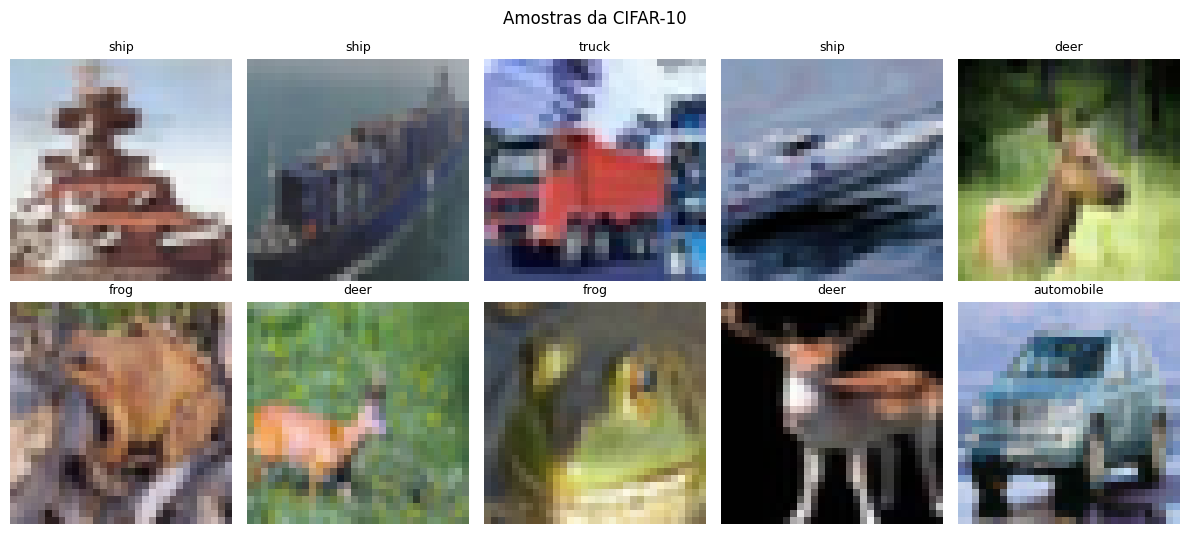

In [40]:
# Inspeção da base
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from common.dataset import load_dataset, reconstruct_images

if DATASET_AVAILABLE:
    images_flat, labels, class_names = load_dataset(
        CIFAR10_DIR, dataset="cifar10", split="train", limit=5000
    )
    images_rgb = reconstruct_images(images_flat)

    print(f"Shape flat (pickle)      : {images_flat.shape}, dtype={images_flat.dtype}")
    print(f"Shape reconstruído (RGB) : {images_rgb.shape}")
    print(f"Classes                  : {class_names}")

    counts = Counter(labels.tolist())
    print("\nDistribuição de classes na amostra de 5.000 imagens:")
    for c in sorted(counts):
        name = class_names[c] if class_names else str(c)
        print(f"  {name:<12} {counts[c]}")

    fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))
    rng = np.random.default_rng(0)
    for ax, idx in zip(axes.flat, rng.choice(len(images_rgb), size=10, replace=False)):
        ax.imshow(images_rgb[idx].astype(np.uint8))
        label = int(labels[idx])
        ax.set_title(class_names[label] if class_names else str(label), fontsize=9)
        ax.axis("off")
    fig.suptitle("Amostras da CIFAR-10", fontsize=12)
    fig.tight_layout()
    plt.show()
else:
    print("Base não encontrada: veja as figuras salvas em outputs/figures/.")

## 3. Estrutura baseline

A primeira versão (`experiments/baseline/`) é **Python puro**, sem nenhuma otimização: apenas laços `for` explícitos. Ela cumpre dois papéis: referência de **corretude** (todas as outras versões são validadas contra a saída dela) e referência de **desempenho**.

### 3.1 Escala de cinza

```python
def rgb_to_grayscale_single(image_rgb: np.ndarray) -> np.ndarray:
    gray = np.empty((32, 32), dtype=np.float32)
    for i in range(32):
        for j in range(32):
            r = float(image_rgb[i, j, 0])
            g = float(image_rgb[i, j, 1])
            b = float(image_rgb[i, j, 2])
            gray[i, j] = 0.299 * r + 0.587 * g + 0.114 * b
    return gray
```

1.024 iterações interpretadas por imagem, só nesta etapa.

### 3.2 Sobel

Para cada pixel, percorre a vizinhança 3x3 (`di`, `dj` de -1 a 1), aplica os pesos dos kernels horizontal e vertical e trata a borda com um `_clamp()` manual:

```python
def _clamp(v, lo, hi):
    return lo if v < lo else (hi if v > hi else v)
```

O total de chamadas a `_clamp` é o ponto crítico: **2 clamps x 9 vizinhos x 1.024 pixels x N imagens**. Para 5.000 imagens, são 92,16 milhões de chamadas de função Python.

In [41]:
from experiments.baseline.pipeline import process_pipeline as run_baseline

if DATASET_AVAILABLE:
    baseline_result = run_baseline(dataset="cifar10", split="train", limit=5000)
    t = baseline_result.timings
    n = baseline_result.images_rgb.shape[0]

    print("=== Baseline, 5.000 imagens ===")
    print(f"Load data       : {t.load_data_s:.4f} s")
    print(f"Reconstruct RGB : {t.reconstruct_rgb_s:.6f} s")
    print(f"Preprocess      : {t.preprocess_s:.4f} s  (grayscale + Sobel juntos nesta versão)")
    print(f"Total           : {t.total_s:.4f} s")
    print(f"Throughput      : {n / t.total_s:.2f} imagens/s")
    print(f"Tempo por imagem: {1e3 * t.total_s / n:.3f} ms")
else:
    print("Base não encontrada: pulando execução ao vivo do baseline.")

=== Baseline, 5.000 imagens ===
Load data       : 0.0111 s
Reconstruct RGB : 0.000007 s
Preprocess      : 21.4871 s  (grayscale + Sobel juntos nesta versão)
Total           : 21.4982 s
Throughput      : 232.58 imagens/s
Tempo por imagem: 4.300 ms


## 4. Profiling da baseline

Para identificar o gargalo real (e não o suposto), a baseline foi perfilada com `cProfile` sobre 5.000 imagens. O perfil bruto está em `outputs/profiling/baseline_profile.prof`, visualizado abaixo com `snakeviz`.

![](outputs/figures/baseline_profile.png)

In [42]:
# Leitura direta do perfil salvo da baseline
import pstats

p = PROF_DIR / "baseline_profile.prof"
if p.exists():
    stats = pstats.Stats(str(p))
    stats.sort_stats("cumtime").print_stats(8)
else:
    print(f"Perfil não encontrado: {p}")

Thu Jul 23 09:46:53 2026    /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/outputs/profiling/baseline_profile.prof

         92200686 function calls (92200677 primitive calls) in 36.437 seconds

   Ordered by: cumulative time
   List reduced from 149 to 8 due to restriction <8>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   36.437   36.437 /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/experiments/baseline/pipeline.py:57(process_pipeline)
        3    0.000    0.000   36.437   12.146 /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/experiments/baseline/pipeline.py:42(time_block)
        1    0.016    0.016   36.381   36.381 /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/experiments/baseline/preprocessing.py:78(process_images)
     5000   25.945    0.005   33.717    0.007 /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/experiments/baseline/preprocessing.py:32(sobel_single)
 9

### Leitura do profiling

| Função | Chamadas | Tempo cumulativo | % do total |
|---|---|---|---|
| `sobel_single()` | 5.000 | **33,72 s** | ≈ 92,6% |
| `_clamp()` (interno ao Sobel) | 92.160.000 | 7,74 s (tottime) | ≈ 21% |
| `rgb_to_grayscale_single()` | 5.000 | 2,65 s | ≈ 7,3% |
| `load_dataset()` / `pickle.load` | 1 | 0,056 s | ≈ 0,15% |

O pipeline completo levou **36,4 s** para 5.000 imagens sob o profiler (a medição sem profiler fica em ~24 s a 28 s; o `cProfile` cobra caro justamente por instrumentar chamadas de função, e aqui há 92 milhões delas).

Três conclusões diretas:

1. **O Sobel é o gargalo**, com mais de 92% do tempo. E o custo não está na aritmética: está no **overhead de chamada de função Python por pixel, por vizinho, por imagem**.
2. A escala de cinza é secundária (≈7%), pelo mesmo motivo (laços aninhados interpretados).
3. **Ler e reconstruir os dados é irrelevante** (<0,2%). Não vale otimizar essa etapa.

### Qual otimização esse diagnóstico sugere?

O padrão observado (muitas operações aritméticas simples, independentes, repetidas milhões de vezes) tem duas saídas naturais, ambas eliminando o interpretador do laço interno:

- **vetorização**: reescrever as operações como expressões de array, delegando o laço para o C do NumPy;
- **compilação JIT (Numba)**: manter o laço explícito, mas compilá-lo para código de máquina.

A vetorização é a de menor esforço de implementação. O Numba, por preservar os laços, é o único que consegue manter a estrutura original do algoritmo **e** rodar em velocidade nativa, o que se mostra decisivo em volume alto (Seção 7). Multiprocessing e GPU atacam o problema por outro ângulo (mais unidades de execução, não menos overhead por operação) e por isso trazem overheads fixos próprios.

## 5. Apresentação das melhorias

As quatro otimizações desta seção estão ordenadas por **complexidade de implementação**, da mais simples para a mais sofisticada. Isso dá uma segunda métrica de leitura além do tempo bruto: **ganho de performance por unidade de complexidade investida**, que é o que decide manutenção no longo prazo.

| Ordem | Otimização | Complexidade | Ideia central | Ataca o gargalo por |
|---|---|---|---|---|
| 1 | **Vetorizada (NumPy)** | Baixa | Reescreve a lógica em operações de array | Remover o laço do Python |
| 2 | **Numba** | Média | Decorador `@njit` compila o mesmo código para nativo | Compilar o laço |
| 3 | **Multiprocessing** | Média-alta | Distribui imagens entre processos | Somar núcleos de CPU |
| 4 | **GPU (PyTorch/CUDA)** | Alta | Reescreve como operações de tensor | Paralelismo massivo |

As duas primeiras reduzem o custo por operação; as duas últimas multiplicam as unidades de execução. Guardar essa distinção ajuda a ler a Seção 7, e é dela que sai a ideia da Seção 8.

### 5.1 Vetorizada (NumPy): complexidade **baixa**

A escala de cinza vira uma única expressão sobre o array `(N, 32, 32, 3)` inteiro:

```python
def rgb_to_grayscale(images_rgb: np.ndarray) -> np.ndarray:
    images_float = images_rgb.astype(np.float32)
    gray = (0.299 * images_float[..., 0]
            + 0.587 * images_float[..., 1]
            + 0.114 * images_float[..., 2])
    return gray.astype(np.float32)
```

O Sobel usa `np.pad` para tratar todas as bordas de uma vez (substituindo o `_clamp` manual) e soma **deslocamentos do array inteiro** em vez de valor por valor:

```python
def sobel_edges(gray_images: np.ndarray) -> np.ndarray:
    padded = np.pad(gray_images, ((0, 0), (1, 1), (1, 1)), mode="edge")
    gx = (-1.0*padded[:, :-2, :-2] + 1.0*padded[:, :-2, 2:]
          -2.0*padded[:, 1:-1, :-2] + 2.0*padded[:, 1:-1, 2:]
          -1.0*padded[:, 2:, :-2]  + 1.0*padded[:, 2:, 2:])
    gy = ...  # kernel vertical, mesmo princípio
    magnitude = np.sqrt(gx*gx + gy*gy)
    ...       # normalização por imagem, também vetorizada
```

**O que muda:** o laço passa a ser executado dentro do NumPy, em C. 

**Custo escondido:** cada um desses 12 deslocamentos gera um **array temporário completo** de tamanho `N x 32 x 32`. Em volume alto isso significa muito tráfego de memória e pressão de cache, o que é exatamente o motivo pelo qual a vetorização perde para o Numba quando N cresce (Seção 7.3).

### 5.2 Numba: complexidade **média**

O Numba mantém **os mesmos laços explícitos** do baseline e adiciona `@njit`, que compila a função para código de máquina na primeira chamada:

```python
from numba import njit

@njit(cache=True)
def sobel_single_numba(gray_image):
    edges = np.empty((32, 32), dtype=np.float32)
    for i in range(32):
        for j in range(32):
            gx = 0.0
            gy = 0.0
            for di in (-1, 0, 1):
                ii = i + di
                if ii < 0: ii = 0
                elif ii > 31: ii = 31
                for dj in (-1, 0, 1):
                    ...  # mesma lógica do baseline, agora compilada
    return edges
```

**O que muda:** o código-fonte é quase idêntico ao baseline (mesmos `for`, mesmo clamping inline em vez de chamada de função). A diferença é que o Numba traduz isso para código nativo, com duas vantagens sobre a vetorização:

- **fusão de laços:** grayscale, gradiente, magnitude e normalização acontecem em uma única passada por imagem, sem criar arrays temporários intermediários;
- **localidade de cache:** cada imagem de 32x32 cabe folgada em cache L1/L2, então o dado é lido uma vez e reaproveitado.

**Custo:** a compilação JIT. É um custo **fixo** (alguns segundos, independente de N) pago na primeira chamada de cada assinatura de função. `cache=True` grava o binário em disco para não recompilar em execuções futuras do mesmo código. Toda a discussão da Seção 6 gira em torno de contabilizar esse custo corretamente.

### 5.3 Multiprocessing: complexidade **média-alta**

Distribui as imagens entre processos do sistema operacional, cada um rodando uma cópia do código **baseline** sobre um chunk:

```python
def process_chunk(images_chunk: np.ndarray):
    gray_list, edge_list = [], []
    for image in images_chunk:
        gray = rgb_to_grayscale_single(image)   # código do baseline
        edges = sobel_single(gray)
        gray_list.append(gray); edge_list.append(edges)
    return np.stack(gray_list), np.stack(edge_list)

def process_images_parallel(images_rgb, processes=None):
    processes = processes or max(1, mp.cpu_count() - 1)
    chunks = split_chunks(images_rgb, processes * 4)
    with mp.Pool(processes=processes) as pool:
        results = pool.map(process_chunk, chunks)
    return (np.concatenate([r[0] for r in results]),
            np.concatenate([r[1] for r in results]))
```

**O que muda:** não o algoritmo, apenas a **distribuição do trabalho**. Isso deixa explícito o limite da abordagem: o código continua sendo Python interpretado, então o ganho máximo é o número de núcleos. O speedup medido (≈2,2x) fica bem abaixo disso por causa do custo de criar processos e serializar (pickle) os chunks de ida e de volta. Multiprocessing paraleliza um trabalho ineficiente em vez de torná-lo eficiente. Guarde esse diagnóstico: ele é específico (serialização entre processos e código interpretado), e é justamente por ser específico que ele deixa uma porta aberta, explorada na Seção 8.

### 5.4 GPU (PyTorch/CUDA): complexidade **alta**

Reescreve o processamento como operações de tensor, inclusive usando a convolução 2D nativa do PyTorch para o Sobel:

```python
def rgb_to_grayscale_torch(images_rgb, device="auto"):
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x = torch.from_numpy(images_rgb).to(dev).permute(0, 3, 1, 2).float()
    return 0.299*x[:, 0:1] + 0.587*x[:, 1:2] + 0.114*x[:, 2:3]

def sobel_edges_torch(gray_images):
    kernel_x = torch.tensor([[[-1,0,1],[-2,0,2],[-1,0,1]]], ...)
    kernel_y = torch.tensor([[[-1,-2,-1],[0,0,0],[1,2,1]]], ...)
    padded = F.pad(gray_images, (1,1,1,1), mode="replicate")
    gx, gy = F.conv2d(padded, kernel_x), F.conv2d(padded, kernel_y)
    magnitude = torch.sqrt(gx*gx + gy*gy)
    ...
```

**O que muda:** os dados saem da RAM e vão para a memória da GPU (`.to(device)`), e o Sobel passa a ser uma convolução em kernel CUDA otimizado. 

**Custos:** transferência CPU para GPU (fixo por lote, domina em N pequeno), dependência de hardware específico e a maior distância em relação ao código original, o que é relevante para manutenção.

## 6. Metodologia de medição

O Numba tem duas parcelas de custo com naturezas diferentes:

| Parcela | Depende de N? | Quando é paga |
|---|---|---|
| Compilação JIT | Não (custo fixo) | Primeira chamada de cada assinatura, em cada processo sem cache |
| Execução nativa | Sim (linear) | Toda chamada |

Uma primeira medição pode ser pensada rodando cada ponto do benchmark em **subprocesso novo com `NUMBA_CACHE_DIR` limpo**, ou seja, **recompilando tudo em cada medição**. Isso mede um regime específico e pouco realista: "um script CLI de execução única, em uma máquina onde o cache nunca é reaproveitado". Assim, esse resultado reflete um Numba com ~140 s a 178 s de tempo total (Seção 7.2), praticamente constante e independente de N, dominado por compilação.

O regime que interessa em produção é o **quente**: o processo carrega o código uma vez (ou lê o binário do cache em disco) e processa muitos lotes. É esse o regime medido em `scaling_hot.csv`, com warm-up antes da medição. Essa medição é aquela que realmente utiliza das vantagens da compilação JIT: a reutilização do binário pré-compilado.

**Decisão metodológica adotada:** o **regime quente é o resultado principal**, e o custo de compilação é reportado separadamente como um custo fixo de setup, do mesmo jeito que não se contabiliza o tempo de `import torch` ou de inicialização do contexto CUDA no custo por imagem da GPU. Reportar o JIT dentro do tempo de processamento e **não** reportar o setup da GPU seria comparar as duas versões com réguas diferentes.

## 7. Análise de performance

### 7.1 Ponto fixo: 5.000 imagens

Primeiro a comparação em um único tamanho de entrada, com 3 repetições por versão (`benchmark/compare_versions.py`). Entram aqui as quatro versões da Seção 5, sem a GPU, que aparece no escalonamento da Seção 7.3.

In [43]:
import pandas as pd

pd.set_option("display.width", 140)

df_fixed = pd.read_csv(CSV_FIXED)
baseline_time = df_fixed.loc[df_fixed["version"] == "baseline", "mean_total_s"].iloc[0]
df_fixed["speedup_vs_baseline"] = baseline_time / df_fixed["mean_total_s"]
df_fixed["throughput_img_s"] = df_fixed["n_images"] / df_fixed["mean_total_s"]
df_fixed["cv_%"] = 100 * df_fixed["std_total_s"] / df_fixed["mean_total_s"]

cols = ["version", "mean_total_s", "std_total_s", "cv_%", "speedup_vs_baseline", "throughput_img_s"]
print("=== Ponto fixo: 5.000 imagens, CIFAR-10, 3 execuções ===\n")
print(df_fixed.sort_values("mean_total_s")[cols].round(4).to_string(index=False))

=== Ponto fixo: 5.000 imagens, CIFAR-10, 3 execuções ===

        version  mean_total_s  std_total_s     cv_%  speedup_vs_baseline  throughput_img_s
     vectorized        0.1527       0.0173  11.3443             184.8746        32735.0388
          numba        0.2363       0.2491 105.4312             119.5074        21160.7107
multiprocessing       12.5535       0.1522   1.2123               2.2494          398.2958
       baseline       28.2380       2.7073   9.5874               1.0000          177.0661


**Leitura da tabela (5.000 imagens):**

| Versão | Tempo médio | Speedup vs. baseline |
|---|---|---|
| Vetorizada (NumPy) | 0,153 s | ≈ 185x |
| Numba | 0,236 s | ≈ 120x |
| Multiprocessing | 12,55 s | ≈ 2,25x |
| Baseline | 28,24 s | 1x (referência) |

Dois pontos merecem atenção, e os dois apontam para o mesmo lugar:

1. **O desvio padrão do Numba é enorme:** 0,249 s de desvio para uma média de 0,236 s, ou seja, coeficiente de variação acima de 100%. Isso não é ruído: é a assinatura de uma primeira execução que pagou compilação e de duas seguintes que não pagaram. A média de três repetições nessas condições **não descreve nenhuma das execuções**. O `min_total_s` é a estimativa honesta do regime quente aqui.
2. **Em 5.000 imagens as versões rápidas estão empatadas na prática:** 0,15 s contra 0,24 s, com uma parcela relevante do tempo sendo carga do pickle e não processamento. Um único ponto de medição neste volume **não é suficiente** para eleger uma vencedora. É preciso escalar.

O multiprocessing fica em ≈2,25x, muito abaixo do número de núcleos, pelo custo de criação de processos e serialização dos chunks: paraleliza o código lento em vez de acelerá-lo.

### 7.2 O custo de compilação do Numba, medido

O CSV `scaling_numba_cold.csv` foi gerado com o Numba em **subprocesso novo e cache limpo em cada ponto**. Ele não serve como resultado principal, mas é a melhor evidência quantitativa do custo fixo do JIT. Vale registrar que a compilação com `parallel=True` é ainda mais cara que a do `njit` simples, porque o Numba precisa analisar o laço e gerar o código de distribuição entre threads: mais um motivo para tratar esse custo como setup e não como processamento.

=== Numba medido a frio (recompilando em cada ponto) ===

 n_images  baseline  vectorized    numba  multiprocessing    gpu
      100    0.5335      0.0214 155.6593           0.3387 0.0749
      500    2.9596      0.0509 178.4293           0.8634 0.0685
     1000    5.0439      0.0457 145.7551           2.0802 0.0915
     2000   10.1132      0.0611 146.4856           3.9022 0.0960
     5000   24.2096      0.1384 140.0170          10.5440 0.1020

Numba frio: tempo praticamente constante e independente de N
  média : 153.3 s
  faixa : 140.0 s a 178.4 s

Com 5.000 imagens:
  quente        : 0.078 s
  frio          : 140.0 s
  custo do JIT  : ~139.9 s (fixo, pago uma vez por processo sem cache)


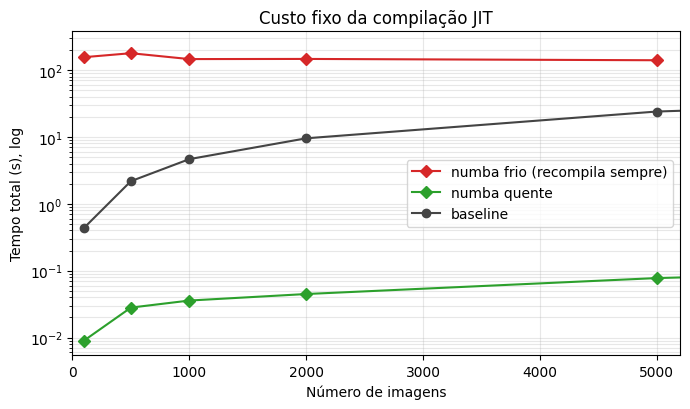

In [44]:
import matplotlib.pyplot as plt

# esta seção precisa do regime quente como referência; a curva completa vem na 7.3
df_hot = pd.read_csv(CSV_HOT)
df_hot = df_hot[df_hot["n_images"] <= 50_000].reset_index(drop=True)

if CSV_COLD is None:
    print("CSV de Numba frio não encontrado.")
else:
    df_cold = pd.read_csv(CSV_COLD)
    print("=== Numba medido a frio (recompilando em cada ponto) ===\n")
    print(df_cold.round(4).to_string(index=False))

    print("\nNumba frio: tempo praticamente constante e independente de N")
    print(f"  média : {df_cold['numba'].mean():.1f} s")
    print(f"  faixa : {df_cold['numba'].min():.1f} s a {df_cold['numba'].max():.1f} s")

    hot = float(df_hot.loc[df_hot["n_images"] == 5000, "numba"].iloc[0])
    cold = float(df_cold.loc[df_cold["n_images"] == 5000, "numba"].iloc[0])
    print("\nCom 5.000 imagens:")
    print(f"  quente        : {hot:.3f} s")
    print(f"  frio          : {cold:.1f} s")
    print(f"  custo do JIT  : ~{cold - hot:.1f} s (fixo, pago uma vez por processo sem cache)")

    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(df_cold["n_images"], df_cold["numba"], marker="D", color="#d62728",
            label="numba frio (recompila sempre)")
    ax.plot(df_hot["n_images"], df_hot["numba"], marker="D", color="#2ca02c",
            label="numba quente")
    ax.plot(df_hot["n_images"], df_hot["baseline"], marker="o", color="#444444",
            label="baseline")
    ax.set(xlabel="Número de imagens", ylabel="Tempo total (s), log",
           title="Custo fixo da compilação JIT", xlim=(0, 5200))
    ax.set_yscale("log"); ax.legend(); ax.grid(alpha=0.3, which="both")
    fig.tight_layout(); plt.show()

A curva a frio é **plana**: o tempo não depende do número de imagens, porque quase todo ele é compilação. Isso confirma que o JIT é um custo de **setup**, não de processamento. Em uso realista ele é pago uma vez por deploy (e evitado pelo `cache=True` em execuções seguintes), enquanto o processamento acontece milhares de vezes.

**Consequência prática**: o único cenário em que a vetorização seria preferível ao Numba é um script de execução única, disparado em um processo novo, sem cache, sobre um volume pequeno. Fora desse caso, o Numba vence.

### 7.3 Escalonamento do volume de dados

O benchmark foi repetido variando o número de imagens de 100 até o dataset de treino inteiro, em regime quente (Seção 6).

In [45]:
df_scaling = pd.read_csv(CSV_HOT)   # recarrega para manter esta seção autocontida
VERSIONS = ["baseline", "vectorized", "numba", "multiprocessing", "gpu"]

# O split de treino tem 50.000 imagens: linhas acima disso repetem o mesmo volume.
MAX_TRAIN = 50_000
dropped = df_scaling[df_scaling["n_images"] > MAX_TRAIN]
df_scaling = df_scaling[df_scaling["n_images"] <= MAX_TRAIN].reset_index(drop=True)
if len(dropped):
    print(
        f"Linhas descartadas por exceder o split de treino ({MAX_TRAIN} imagens): "
        f"{sorted(dropped['n_images'].tolist())}\n"
    )

print("=== Tempo total (s) por versão x número de imagens ===\n")
print(df_scaling.round(4).to_string(index=False))

# tempo por imagem (microssegundos) para ver custo marginal
per_img = df_scaling.copy()
for v in VERSIONS:
    per_img[v] = 1e6 * per_img[v] / per_img["n_images"]
print("\n=== Tempo por imagem (µs) ===\n")
print(per_img.round(2).to_string(index=False))

Linhas descartadas por exceder o split de treino (50000 imagens): [60000]

=== Tempo total (s) por versão x número de imagens ===

 n_images  baseline  vectorized  numba  multiprocessing    gpu
      100    0.4385      0.0106 0.0090           0.2073 0.0551
      500    2.1783      0.0323 0.0281           0.7754 0.0652
     1000    4.6538      0.0451 0.0358           1.5574 0.0701
     2000    9.5305      0.0574 0.0448           3.2801 0.0891
     5000   23.9561      0.1313 0.0776           9.8537 0.0938
    10000   45.7732      0.3713 0.1321          20.1509 0.1492
    15000   68.6287      0.5829 0.2295          32.5290 0.2170
    20000   94.8904      0.7490 0.2944          41.1251 0.2503
    30000  137.9126      1.2088 0.4304          64.5228 0.4110
    40000  189.5675      1.6180 0.5812          84.4676 0.5114
    50000  228.2225      1.9269 0.7146         105.1309 0.5536

=== Tempo por imagem (µs) ===

 n_images  baseline  vectorized  numba  multiprocessing    gpu
      100   4385.3

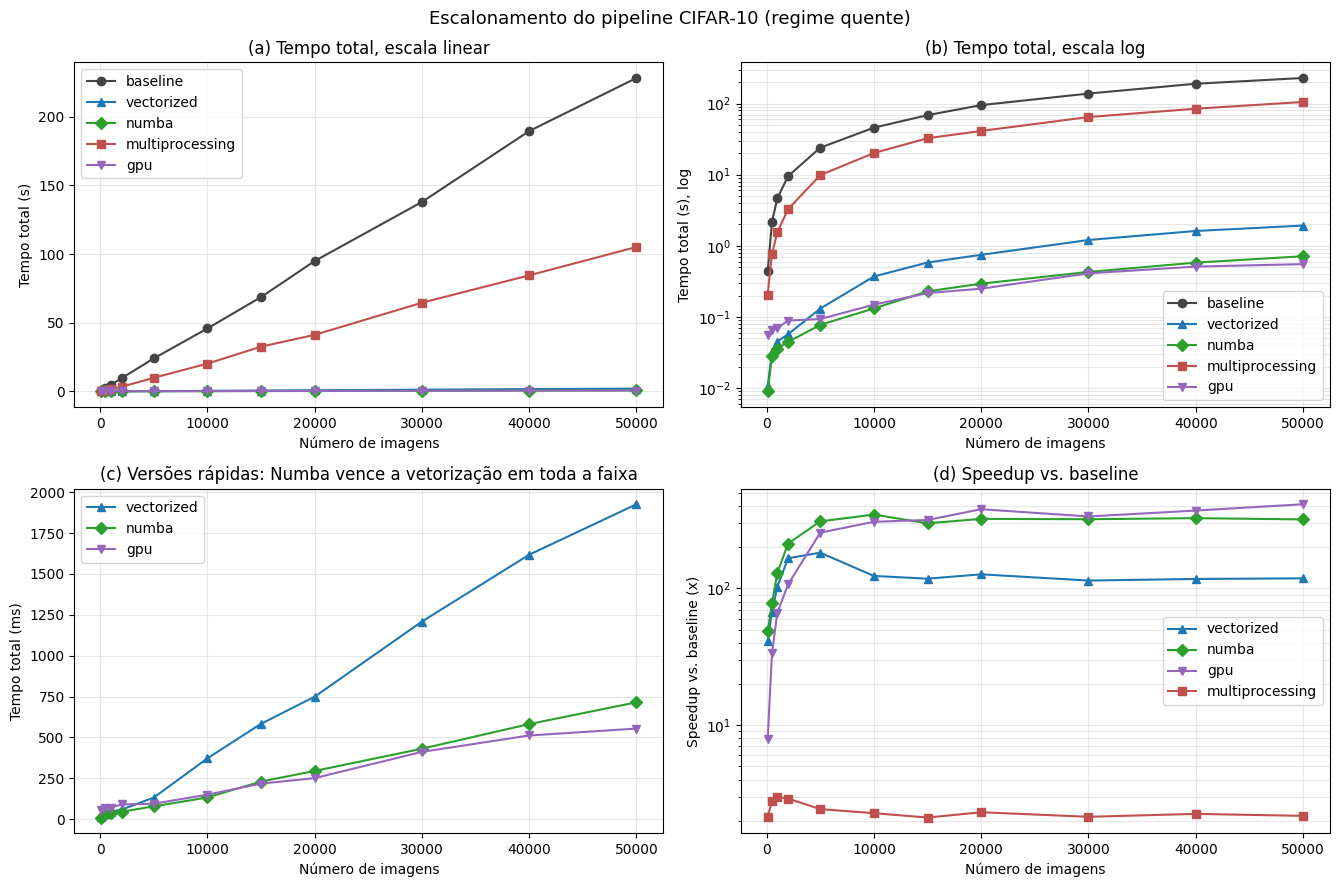

In [46]:
import matplotlib.pyplot as plt

STYLE = {
    "baseline":        dict(color="#444444", marker="o"),
    "multiprocessing": dict(color="#c0504d", marker="s"),
    "vectorized":      dict(color="#1f77b4", marker="^"),
    "numba":           dict(color="#2ca02c", marker="D"),
    "numba_parallel":  dict(color="#17becf", marker="P"),
    "gpu":             dict(color="#9467bd", marker="v"),
}
n = df_scaling["n_images"]

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9))

# (a) escala linear: mostra a dominância da baseline
ax = axes[0, 0]
for v in VERSIONS:
    ax.plot(n, df_scaling[v], label=v, **STYLE[v])
ax.set(xlabel="Número de imagens", ylabel="Tempo total (s)",
       title="(a) Tempo total, escala linear")
ax.legend(); ax.grid(alpha=0.3)

# (b) escala log: separa as versões rápidas
ax = axes[0, 1]
for v in VERSIONS:
    ax.plot(n, df_scaling[v], label=v, **STYLE[v])
ax.set(xlabel="Número de imagens", ylabel="Tempo total (s), log",
       title="(b) Tempo total, escala log")
ax.set_yscale("log"); ax.legend(); ax.grid(alpha=0.3, which="both")

# (c) só as versões rápidas, em ms: aqui aparece o cruzamento
ax = axes[1, 0]
for v in ["vectorized", "numba", "gpu"]:
    ax.plot(n, 1e3 * df_scaling[v], label=v, **STYLE[v])
ax.set(xlabel="Número de imagens", ylabel="Tempo total (ms)",
       title="(c) Versões rápidas: Numba vence a vetorização em toda a faixa")
ax.legend(); ax.grid(alpha=0.3)

# (d) speedup vs baseline
ax = axes[1, 1]
for v in ["vectorized", "numba", "gpu", "multiprocessing"]:
    ax.plot(n, df_scaling["baseline"] / df_scaling[v], label=v, **STYLE[v])
ax.set(xlabel="Número de imagens", ylabel="Speedup vs. baseline (x)",
       title="(d) Speedup vs. baseline")
ax.set_yscale("log"); ax.legend(); ax.grid(alpha=0.3, which="both")

fig.suptitle("Escalonamento do pipeline CIFAR-10 (regime quente)", fontsize=13)
fig.tight_layout()
plt.show()

In [47]:
# Números-chave no maior volume medido e cruzamento Numba x GPU
row = df_scaling.iloc[-1]
n_max = int(row["n_images"])

print(f"=== {n_max} imagens ===")
for v in sorted(VERSIONS, key=lambda x: row[x]):
    print(f"  {v:<16} {row[v]:>9.3f} s   speedup {row['baseline'] / row[v]:>7.1f}x"
          f"   {1e6 * row[v] / n_max:>7.2f} µs/img")

print(f"\nNumba vs. vetorizada : {row['vectorized'] / row['numba']:.2f}x mais rápido")
print(f"Numba vs. GPU        : {row['numba'] / row['gpu']:.2f}x do tempo da GPU")

faster = df_scaling[df_scaling["gpu"] < df_scaling["numba"]]
if len(faster):
    print(f"\nGPU passa a ser mais rápida que o Numba a partir de "
          f"~{int(faster['n_images'].iloc[0])} imagens.")
else:
    print("\nA GPU não supera o Numba em nenhum volume medido.")

=== 50000 imagens ===
  gpu                  0.554 s   speedup   412.2x     11.07 µs/img
  numba                0.715 s   speedup   319.4x     14.29 µs/img
  vectorized           1.927 s   speedup   118.4x     38.54 µs/img
  multiprocessing    105.131 s   speedup     2.2x   2102.62 µs/img
  baseline           228.222 s   speedup     1.0x   4564.45 µs/img

Numba vs. vetorizada : 2.70x mais rápido
Numba vs. GPU        : 1.29x do tempo da GPU

GPU passa a ser mais rápida que o Numba a partir de ~15000 imagens.


**Leitura do escalonamento:**

- **Baseline:** cresce linearmente com uma constante altíssima. Comportamento O(n) esperado, com o custo por imagem dominado pelo overhead de interpretação. Serve apenas de régua.
- **Multiprocessing:** também linear, com constante ≈2,2x menor que a baseline. O speedup fica muito abaixo do número de núcleos porque o trabalho útil por chunk não amortiza a serialização, e porque o que roda dentro de cada processo continua sendo Python puro.
- **Vetorizada (NumPy):** ordens de magnitude melhor que a baseline, mas com custo marginal por imagem **crescente** em volume alto. Isso acontece, porque os arrays temporários dos 12 deslocamentos do Sobel (Seção 5.1) passam a não caber em cache, e a operação vira limitada por banda de memória.
- **Numba:** o melhor custo marginal em toda a faixa medida, e a diferença **aumenta** com o volume, chegando a **≈2,7x mais rápido que a vetorização** com 50.000 imagens. A razão é estrutural: laços fundidos, uma passada por imagem, nenhum array temporário e dado quente em cache. É o caso em que "manter o laço explícito e compilá-lo" ganha de "eliminar o laço".
- **GPU:** custo fixo de transferência CPU para GPU domina em volume pequeno (fica atrás do Numba até ~10.000 a 15.000 imagens) e se dilui depois, quando a GPU assume a liderança. A margem final, porém, é modesta (menos de 1,4x sobre o Numba), o que é pouco para justificar dependência de hardware dedicado neste problema específico: as imagens são pequenas e o pipeline por imagem é leve. Além disso, essa implementação é, também, aquela que exige maior esforço cognitivo e de manutenção.

**O ponto que não fecha.** O Numba é a melhor versão em CPU e se mantém performático em toda a faixa, e mesmo assim a GPU o supera a partir de ~15.000 imagens, abrindo distância conforme o volume cresce. Aceitar isso como resultado final significa aceitar que processar imagens em escala exige hardware dedicado. Antes disso, vale entender de onde vem a vantagem da GPU: é o que a Seção 8 faz, e é de onde sai a otimização mais eficiente deste projeto.

## 8. A ideia que a análise sugere: paralelizar o Numba

### 8.1 O raciocínio

A Seção 7 termina com um incômodo. O Numba é a melhor versão em CPU por uma margem folgada e se mantém performático em toda a faixa medida, e mesmo assim **a GPU passa à frente dele a partir de ~15.000 imagens**, com a distância crescendo conforme o volume aumenta. Antes de aceitar isso como conclusão, vale perguntar de onde vem essa vantagem.

Não vem de calcular melhor. As duas versões fazem a mesma aritmética, a mesma luminância e o mesmo Sobel 3x3, e `benchmark/verify_pipeline.py` confirma que as saídas coincidem. A GPU ganha por um motivo só: ela processa **muitas imagens ao mesmo tempo**. Já a versão Numba, por bem compilada que esteja, percorre o laço de imagens **em uma única thread**: uma imagem, depois a próxima, em um núcleo, com os outros parados.

Dito assim, fica evidente que existe desempenho não aproveitado, e duas coisas que o projeto já tinha estabelecido se encaixam:

- o problema é **paralelo por natureza** (Seção 1): cada imagem é independente das demais, sem estado compartilhado entre elas;
- o multiprocessing (Seção 5.3) tentou explorar exatamente isso e rendeu apenas ≈2,2x. Mas o diagnóstico daquele resultado fraco foi **específico**: serializar chunks de imagens entre processos e paralelizar código ainda interpretado. Nenhuma dessas duas objeções se aplica a threads operando sobre código já compilado, dentro do mesmo espaço de memória.

Ou seja, o obstáculo que limitou o multiprocessing não está presente aqui. Sobra uma pergunta direta:

> **E se o laço que já está compilado for distribuído entre os núcleos da CPU?**

A previsão, se a leitura estiver certa, é que o ganho seja da ordem do número de núcleos úteis, e que a distância até a GPU encurte ou desapareça. A hipótese tem uma vantagem prática: é simples de testar.

### 8.2 A implementação: uma linha de código

O Numba oferece exatamente isso. `range` vira `prange` e o decorador ganha `parallel=True`:

```python
from numba import njit, prange

@njit(parallel=True, cache=True)
def process_images_numba_parallel(images_rgb):
    n = images_rgb.shape[0]
    grays = np.empty((n, 32, 32), dtype=np.float32)
    edges = np.empty((n, 32, 32), dtype=np.float32)

    for idx in prange(n):                       # única mudança de verdade
        _grayscale_into(images_rgb[idx], grays[idx])
        _sobel_into(grays[idx], edges[idx])

    return grays, edges
```

A implementação está em `experiments/numba_parallel/`, e três decisões foram tomadas para que o experimento respondesse à pergunta da Seção 8.1 sem contaminação:

1. **A aritmética por pixel é idêntica à da versão serial**, deliberadamente. Nenhuma outra otimização foi introduzida junto, então qualquer diferença de tempo é atribuível só ao paralelismo.
2. **Cada iteração escreve apenas em `grays[idx]` e `edges[idx]`.** Não há escrita compartilhada nem redução em ponto flutuante entre threads, o que garante resultado determinístico: a saída é **bit a bit idêntica** à da versão serial. `benchmark/verify_pipeline.py` compara as duas com tolerância zero, além de comparar ambas contra a baseline.
3. **O número de threads é controlável** via `numba.set_num_threads`, o que permite medir a escalabilidade em vez de apenas aceitar o default (Seção 8.4).

**Custo da mudança:** a compilação com `parallel=True` é bem mais lenta que a do `njit` simples, porque o Numba precisa analisar o laço e gerar o código de distribuição entre threads. Vale a mesma decisão metodológica da Seção 6: isso é custo de setup, pago uma vez e amortizado pelo cache em disco, não custo de processamento.

**Comparando com o multiprocessing lado a lado**: as duas técnicas somam núcleos de CPU, mas uma distribui laço compilado com memória compartilhada e a outra distribui laço interpretado pagando pickle a cada troca. A Seção 8.3 mostra o tamanho dessa diferença.

### 8.3 O que a medição diz

`benchmark/scaling_parallel.py` mede as quatro versões rápidas lado a lado, na mesma execução e todas em regime quente: vetorizada, Numba serial, Numba paralelo e GPU.

**Uma ressalva de método antes dos números.** Esse benchmark rodou em uma sessão separada da Seção 7.3, e as versões presentes nos dois arquivos ficaram de 14% a 41% mais lentas na segunda medição, na mesma máquina e com o mesmo código. Isso é variação de sessão: estado térmico, frequência da CPU, cache de disco e o que mais estivesse rodando. A consequência é que **não se compara coluna entre arquivos diferentes**. Toda razão abaixo é calculada dentro de `scaling_parallel.csv`, onde as quatro versões foram medidas sob as mesmas condições.

In [48]:
df_par = pd.read_csv(CSV_PARALLEL)
FAST = ["vectorized", "numba", "numba_parallel", "gpu"]

print("=== Tempo total (s), quatro versões rápidas na mesma execução ===\n")
print(df_par.round(4).to_string(index=False))

per_img_par = df_par.copy()
for v in FAST:
    per_img_par[v] = 1e6 * per_img_par[v] / per_img_par["n_images"]
print("\n=== Tempo por imagem (µs) ===\n")
print(per_img_par.round(2).to_string(index=False))

=== Tempo total (s), quatro versões rápidas na mesma execução ===

 n_images  vectorized  numba  numba_parallel    gpu
      100      0.0232 0.0227          0.0268 0.0796
      500      0.0427 0.0375          0.0403 0.0837
     1000      0.0558 0.0464          0.0459 0.0874
     2000      0.0755 0.0578          0.0500 0.0926
     5000      0.1624 0.1018          0.0818 0.1098
    10000      0.3781 0.1835          0.1267 0.1534
    15000      0.5981 0.2537          0.1871 0.2252
    20000      0.7896 0.3667          0.2625 0.2748
    30000      1.2454 0.5368          0.3954 0.3976
    40000      1.8249 0.7583          0.5384 0.5047
    50000      2.4011 1.0441          0.7646 0.7114

=== Tempo por imagem (µs) ===

 n_images  vectorized  numba  numba_parallel    gpu
      100      232.02 226.69          267.73 796.44
      500       85.44  74.98           80.51 167.48
     1000       55.80  46.38           45.93  87.44
     2000       37.73  28.88           24.99  46.29
     5000       3

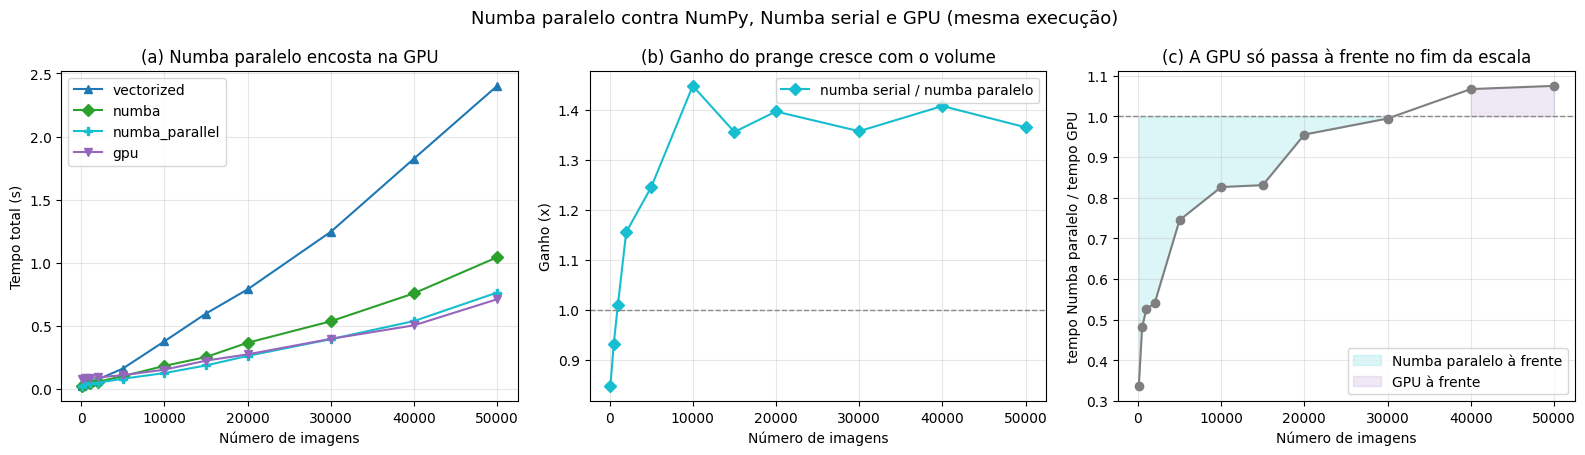

In [49]:
n_par = df_par["n_images"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) tempo total das quatro versões rápidas
ax = axes[0]
for v in FAST:
    ax.plot(n_par, df_par[v], label=v, **STYLE[v])
ax.set(xlabel="Número de imagens", ylabel="Tempo total (s)",
       title="(a) Numba paralelo encosta na GPU")
ax.legend(); ax.grid(alpha=0.3)

# (b) ganho do prange sobre o Numba serial
ax = axes[1]
ax.plot(n_par, df_par["numba"] / df_par["numba_parallel"], color=STYLE["numba_parallel"]["color"],
        marker="D", label="numba serial / numba paralelo")
ax.axhline(1.0, color="#888888", lw=1, ls="--")
ax.set(xlabel="Número de imagens", ylabel="Ganho (x)",
       title="(b) Ganho do prange cresce com o volume")
ax.legend(); ax.grid(alpha=0.3)

# (c) razão CPU/GPU: onde cada uma ganha
ax = axes[2]
ratio = df_par["numba_parallel"] / df_par["gpu"]
ax.plot(n_par, ratio, color="#7f7f7f", marker="o")
ax.axhline(1.0, color="#888888", lw=1, ls="--")
ax.fill_between(n_par, 1.0, ratio, where=(ratio <= 1.0), alpha=0.15,
                color=STYLE["numba_parallel"]["color"], label="Numba paralelo à frente")
ax.fill_between(n_par, 1.0, ratio, where=(ratio > 1.0), alpha=0.15,
                color=STYLE["gpu"]["color"], label="GPU à frente")
ax.set(xlabel="Número de imagens", ylabel="tempo Numba paralelo / tempo GPU",
       title="(c) A GPU só passa à frente no fim da escala")
ax.legend(); ax.grid(alpha=0.3)

fig.suptitle("Numba paralelo contra NumPy, Numba serial e GPU (mesma execução)", fontsize=13)
fig.tight_layout()
plt.show()

In [50]:
import numpy as np

row = df_par.iloc[-1]
n_max_par = int(row["n_images"])

print(f"=== {n_max_par} imagens (mesma execução) ===")
for v in sorted(FAST, key=lambda x: row[x]):
    print(f"  {v:<16} {row[v]:>8.3f} s   {1e6 * row[v] / n_max_par:>6.2f} µs/img")

print(f"\nNumba paralelo vs Numba serial : {row['numba'] / row['numba_parallel']:.2f}x")
print(f"Numba paralelo vs vetorizada   : {row['vectorized'] / row['numba_parallel']:.2f}x")
print(f"Numba paralelo vs GPU          : {row['numba_parallel'] / row['gpu']:.3f}x do tempo da GPU "
      f"({100 * (row['numba_parallel'] / row['gpu'] - 1):.1f}% mais lento)")

# custo marginal por imagem: coeficiente angular do ajuste linear
print("\n=== Custo marginal (ajuste linear para n >= 5.000) ===")
big = df_par[df_par["n_images"] >= 5000]
for v in FAST:
    slope, intercept = np.polyfit(big["n_images"], big[v], 1)
    print(f"  {v:<16} {1e6 * slope:>6.2f} µs por imagem adicional")

# onde a GPU assume a liderança
ahead = df_par[df_par["numba_parallel"] < df_par["gpu"]]
if len(ahead):
    print(f"\nNumba paralelo é mais rápido que a GPU até {int(ahead['n_images'].max())} imagens.")

=== 50000 imagens (mesma execução) ===
  gpu                 0.711 s    14.23 µs/img
  numba_parallel      0.765 s    15.29 µs/img
  numba               1.044 s    20.88 µs/img
  vectorized          2.401 s    48.02 µs/img

Numba paralelo vs Numba serial : 1.37x
Numba paralelo vs vetorizada   : 3.14x
Numba paralelo vs GPU          : 1.075x do tempo da GPU (7.5% mais lento)

=== Custo marginal (ajuste linear para n >= 5.000) ===
  vectorized        49.38 µs por imagem adicional
  numba             20.55 µs por imagem adicional
  numba_parallel    14.88 µs por imagem adicional
  gpu               12.90 µs por imagem adicional

Numba paralelo é mais rápido que a GPU até 30000 imagens.


**Leitura: a hipótese se confirma.**

- **O `prange` entrega 1,37x sobre o Numba serial** com 50.000 imagens (1,044 s contra 0,765 s), e o ganho **cresce com o volume**: é praticamente nulo com 100 imagens, onde coordenar threads não se paga, e sobe de forma consistente a partir de ~2.000. Painel (b).
- **Contra a vetorizada, o ganho é de 3,14x** no maior volume, e o custo marginal conta a mesma história: ~14,9 µs contra ~49,4 µs por imagem adicional.
- **A resposta à pergunta da Seção 8.1 é a parte mais importante.** O Numba paralelo é **mais rápido que a GPU em todos os volumes até 30.000 imagens**, e a GPU só recupera a liderança em 40.000 e 50.000, com margem de **7,5%** no ponto final (0,765 s contra 0,711 s). Painel (c). A vantagem que a GPU tinha na Seção 7.2 era, em boa parte, apenas o fato de estar comparando paralelo contra serial.
- Vale registrar que a GPU foi a versão de **medição mais instável**: desvio padrão de 0,13 s em 0,71 s no maior volume, contra 0,05 s do Numba paralelo (`scaling_parallel_detail.csv`). A margem de 7,5% é menor que a própria variação da GPU.

Em resumo: uma linha de código sobre uma versão que já existia colocou a CPU no mesmo patamar de um caminho que exige reescrever o pipeline em tensores, instalar PyTorch e depender de uma GPU com CUDA.

Isso levanta a pergunta seguinte, que a Seção 8.4 responde: se distribuir o laço entre threads funcionou, **quanto ainda há para ganhar adicionando mais threads?**

### 8.4 Escalabilidade por número de threads

Paralelizar levanta uma pergunta que o tempo total não responde: **quanto de cada núcleo adicional está sendo realmente aproveitado?** A varredura abaixo repete o mesmo volume (50.000 imagens) variando o número de threads do Numba.

=== Numba paralelo: 50.000 imagens, variando threads ===

 threads  n_images  mean_s  std_s  min_s  speedup_vs_min_threads  efficiency
       1     50000  1.3636 0.0683 1.2869                  1.0000      1.0000
       2     50000  0.9348 0.0154 0.9177                  1.4587      0.7294
       4     50000  0.8685 0.0267 0.8379                  1.5702      0.3925
       8     50000  0.8107 0.0225 0.7847                  1.6820      0.2103

Speedup observado com 8 threads: 1.68x
Fração serial implícita (lei de Amdahl): 54% do tempo total
Teto de speedup com essa fração serial: 1.9x, por mais threads que se adicione


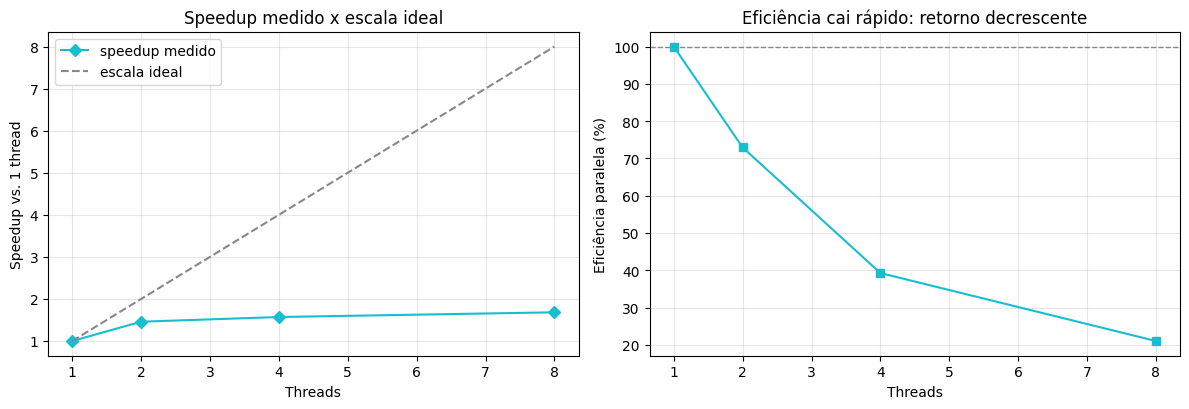

In [51]:
df_thr = pd.read_csv(CSV_THREADS)

print("=== Numba paralelo: 50.000 imagens, variando threads ===\n")
print(df_thr.round(4).to_string(index=False))

# fração serial implícita, por Amdahl, a partir do speedup observado
t_max = int(df_thr["threads"].max())
s_max = float(df_thr.loc[df_thr["threads"] == t_max, "speedup_vs_min_threads"].iloc[0])
serial_frac = (t_max / s_max - 1) / (t_max - 1)
print(f"\nSpeedup observado com {t_max} threads: {s_max:.2f}x")
print(f"Fração serial implícita (lei de Amdahl): {100 * serial_frac:.0f}% do tempo total")
print(f"Teto de speedup com essa fração serial: {1 / serial_frac:.1f}x, "
      f"por mais threads que se adicione")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.plot(df_thr["threads"], df_thr["speedup_vs_min_threads"], marker="D",
        color=STYLE["numba_parallel"]["color"], label="speedup medido")
ax.plot(df_thr["threads"], df_thr["threads"], ls="--", color="#888888", label="escala ideal")
ax.set(xlabel="Threads", ylabel="Speedup vs. 1 thread",
       title="Speedup medido x escala ideal")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df_thr["threads"], 100 * df_thr["efficiency"], marker="s",
        color=STYLE["numba_parallel"]["color"])
ax.axhline(100, ls="--", color="#888888", lw=1)
ax.set(xlabel="Threads", ylabel="Eficiência paralela (%)",
       title="Eficiência cai rápido: retorno decrescente")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

**Leitura:**

- **A primeira thread extra paga bem, as seguintes não.** De 1 para 2 threads o ganho é de 1,46x (eficiência de 73%); de 2 para 8, o tempo cai apenas de 0,935 s para 0,811 s. Com 8 threads, o speedup total é de 1,68x e a eficiência caiu para 21%.
- **Isso não é defeito do `prange`, é a lei de Amdahl.** O speedup observado implica que **mais da metade do tempo total é serial**, e a Seção 8.5 localiza exatamente onde: a leitura do pickle e a cópia para memória contígua rodam em uma única thread, fora do laço paralelo. Nenhuma quantidade de threads acelera essa parte.
- Duas causas secundárias: o trabalho por imagem é minúsculo (uma imagem de 32x32 é processada em microssegundos, então a coordenação entre threads pesa relativamente muito) e threads lógicas não são núcleos físicos, o que costuma explicar o quase-empate entre 4 e 8.
- **Consequência prática:** o investimento ideal aqui é baixo. Rodar com 2 a 4 threads captura quase todo o ganho disponível; ir além só consome núcleos que poderiam estar processando outro lote.

A curva foi medida com o tempo **total** do pipeline, incluindo a carga de dados. Essa é a régua honesta para decidir configuração de execução, mas ela mistura a parte paralelizável com a que não é, e é justamente essa mistura que a próxima seção decompõe.

### 8.5 Olhando dentro da versão vencedora

A baseline foi perfilada na Seção 4, quando o Sobel consumia 92,6% do tempo. Perfilando agora o Numba paralelo já compilado (`outputs/profiling/numba_parallel_profile.prof`, gerado com `--warmup`), o quadro está completamente invertido, e aparece o custo que explica a Seção 8.4.

In [52]:
p = PROF_DIR / "numba_parallel_profile.prof"
if p.exists():
    stats_par = pstats.Stats(str(p))
    stats_par.sort_stats("tottime").print_stats(8)
else:
    print(f"Perfil não encontrado: {p}")

Tue Jul 28 22:21:52 2026    /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/outputs/profiling/numba_parallel_profile.prof

         744 function calls (735 primitive calls) in 0.095 seconds

   Ordered by: internal time
   List reduced from 156 to 8 due to restriction <8>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.041    0.021    0.042    0.021 {built-in method _pickle.load}
        1    0.026    0.026    0.026    0.026 {built-in method numpy.ascontiguousarray}
        1    0.023    0.023    0.023    0.023 /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/experiments/numba_parallel/preprocessing.py:141(process_images_numba_parallel)
        1    0.003    0.003    0.046    0.046 /home/malusevilha/7-semestre/CompDes/projeto-final-compdes/common/dataset.py:79(load_dataset)
        2    0.000    0.000    0.000    0.000 {built-in method numpy.asarray}
       16    0.000    0.000    0.000    0.000 {built-in method posix.stat}
 

**Leitura do profiling do Numba paralelo (5.000 imagens, já compilado):**

| Etapa | Tempo | % do total |
|---|---|---|
| Total do pipeline | 0,095 s | 100% |
| `load_dataset()` (essencialmente `pickle.load`) | 0,046 s | ≈ 48% |
| `np.ascontiguousarray()` antes do kernel | 0,026 s | ≈ 27% |
| Kernel paralelo (`process_images_numba_parallel`) | 0,023 s | ≈ 24% |

Três leituras, e as duas últimas são as mais úteis do projeto:

1. **O gargalo original desapareceu.** O processamento que custava 33,7 s na baseline agora custa 23 ms, e o pipeline inteiro cabe em menos de 100 ms. A otimização atingiu seu objetivo.

2. **O gargalo se deslocou para a leitura dos dados.** O `pickle.load` era 0,15% do tempo na baseline e agora é quase metade dele. Nada ficou mais lento: o que mudou foi tudo em volta ficar rápido. Esse é o sinal clássico de otimização bem-sucedida, e aponta o próximo alvo: um formato binário como `.npy` com `memmap`, ou leitura dos batches em paralelo.

3. **A cópia para memória contígua custa mais que o próprio cálculo.** `reconstruct_images()` devolve uma *view* transposta (`reshape` + `transpose`), que não é contígua na memória. A versão paralela chama `np.ascontiguousarray()` para que o kernel percorra a imagem de forma sequencial, e essa cópia custa 26 ms, **mais que os 23 ms do kernel**. Hoje o pipeline gasta mais tempo reorganizando os dados do que processando-os.

O item 3 fecha o raciocínio da Seção 8.4: leitura do pickle e cópia contígua são ambas **seriais**, executam fora do `prange` e somam cerca de três quartos do tempo desta medição. É exatamente a fração serial que a lei de Amdahl aponta como teto do ganho por threads. Se a reconstrução já entregasse um array contíguo, essa cópia sumiria, a fração serial cairia e as duas coisas melhorariam juntas: o tempo total e a escalabilidade por threads. É uma hipótese medível, não um resultado, e está na lista da Seção 9.2.

## 9. Conclusão

### 9.1 Qual a melhor otimização para esse uso?

**Numba paralelo**, e a distância até a GPU é o que sustenta a escolha.

- **O Numba resolve o gargalo diagnosticado na Seção 4** (overhead de interpretação por operação escalar) **sem abrir mão da estrutura do algoritmo**. Isso rende dois ganhos que a vetorização não consegue: laços fundidos em uma única passada por imagem, sem arrays temporários, e localidade de cache. Daí os ≈319x sobre a baseline e os ≈2,7x sobre o NumPy com 50.000 imagens.

- **O `prange` acrescenta 1,37x sobre esse resultado ao custo de uma linha.** É a melhor relação ganho por complexidade de todo o projeto: mesma aritmética, saída bit a bit idêntica (verificada com tolerância zero) e nenhuma dependência nova além do Numba que já estava lá. Vale notar de onde ela veio: não de uma lista de técnicas a testar, mas de perguntar por que a GPU vencia no escalonamento.

- **A vetorização continua sendo o primeiro passo certo.** Uma reescrita curta entrega ~118x sem custo de compilação e sem nenhuma dependência nova. Ela perde para o Numba em volume alto porque cada expressão de array materializa temporários, e a operação passa a ser limitada por banda de memória em vez de CPU.

- **Multiprocessing "perde" por atacar o problema errado.** Multiplica unidades de execução sem reduzir o custo por operação: continua executando código interpretado, agora em paralelo, e pagando serialização a cada troca. Entrega ≈2,2x. O contraste com o `prange` é a lição mais limpa do trabalho: as duas somam núcleos de CPU, e a que parte de código compilado com memória compartilhada ganha por duas ordens de magnitude.

- **A GPU deixou de justificar seu preço.** Ela é mais rápida apenas acima de 30.000 imagens, e por 7,5% no ponto máximo, com a maior variância entre as versões. Do outro lado da balança estão a reescrita completa em tensores, a dependência de CUDA e o custo fixo de transferência. Com imagens de 32x32 e um pipeline leve, não existe trabalho por imagem suficiente para a GPU abrir vantagem. A conclusão mudaria com imagens maiores, com um pipeline mais pesado por imagem (uma CNN inteira, não grayscale mais Sobel) ou se os dados já estivessem na GPU por outro motivo.

**Recomendação por regime de uso:**

| Cenário | Escolha | Justificativa |
|---|---|---|
| Script de execução única, volume pequeno, sem cache | Vetorizada (NumPy) | Evita pagar compilação por uma execução só |
| Serviço ou lote recorrente, CPU apenas | **Numba paralelo, 2 a 4 threads** | Melhor tempo em CPU, JIT amortizado, código próximo do original |
| Máquina compartilhada, vários lotes ao mesmo tempo | Numba serial | Libera núcleos: a eficiência paralela cai rápido (Seção 8.4) |
| Volumes muito acima de 50.000 imagens com GPU já no fluxo | GPU | Vantagem cresce com o volume, se o hardware já está pago |

**Três lições, na ordem em que apareceram:**

1. **A melhor otimização é a que ataca o gargalo apontado pelo profiling.** O gargalo da baseline era overhead de interpretação por operação escalar, e as técnicas que reduzem esse custo (vetorização e compilação) ganharam de longe das que apenas multiplicam unidades de execução.
2. **A medição precisa separar custo de setup de custo de processamento.** Sem essa separação a conclusão se inverte, e a vetorização aparece na frente apenas porque o Numba foi cobrado por um setup que, em uso real, se paga uma única vez. Medir mal é uma forma de errar tão eficiente quanto otimizar a coisa errada.
3. **O gargalo se move, e vale perseguir o próximo.** Foi ao investigar por que a GPU escalava melhor que surgiu a otimização mais eficiente do projeto. E depois dela, com o processamento caindo de 33,7 s para 23 ms, o pipeline passou a gastar quase metade do tempo lendo pickle e mais tempo reorganizando memória do que calculando. A próxima rodada de otimização deste projeto não seria sobre o Sobel.

### 9.2 Limitações e próximos passos

- **Carga de dados como próximo gargalo.** O `pickle.load` é ≈48% do tempo do pipeline otimizado. Formatos binários (`.npy`, `memmap`) ou leitura paralela dos batches são o passo seguinte natural.
- **Eficiência paralela baixa.** Com 8 threads, a eficiência é de 21%. Parte é Amdahl (fração serial), parte é o trabalho minúsculo por imagem e threads lógicas contra núcleos físicos. Separar o tempo do kernel do tempo de I/O na varredura permitiria atribuir cada parcela com precisão.
- **Variação entre sessões.** As mesmas versões ficaram de 14% a 41% mais lentas entre as duas execuções de benchmark, o que reforça a regra de comparar apenas dentro do mesmo arquivo (Seção 8.3) e sugere repetir as medições em mais sessões antes de tratar margens pequenas, como os 7,5% que separam CPU e GPU, como definitivas.
- **Uma máquina, um hardware.** Todos os números vêm de uma única configuração. As conclusões sobre o cruzamento entre CPU e GPU dependem do par CPU/GPU específico.
- **Ainda não testado:** a mesma comparação com imagens maiores, onde a GPU deve dominar com clareza, e `parallel=True` combinado com processamento em blocos, para reaproveitar cache entre imagens vizinhas.
- **Corretude:** todas as versões são validadas contra a baseline por `benchmark/verify_pipeline.py`, e o Numba paralelo é comparado ao serial com tolerância zero, garantindo que paralelizar não alterou a saída.